In [1]:
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

sys.path.insert(0, "../../src")
from renewable_data_load import sim_name_dict, get_gwl_crossing_period

data_dir = Path("../../data/")
facility_dir = Path("facility_locations")
fig_dir = Path("figures/hydro_drought_change")
fig_dir.mkdir(parents=True, exist_ok=True)


In [15]:
# ── Load facility locations ────────────────────────────────────────────────
df_fac = pd.read_csv(
    facility_dir / "WEAP_hydropower_generators_with_avg_annual_generation.csv"
)
df_fac = df_fac[
    ["WEAP_name", "longitude", "latitude", "RoR_or_Reservoir",
     "Avg_Annual_Generation_GWh_SWITCH"]
].rename(columns={"WEAP_name": "facility", "Avg_Annual_Generation_GWh_SWITCH": "avg_gen_gwh"})
print(f"Facility CSV: {len(df_fac)} facilities")
print(df_fac["RoR_or_Reservoir"].value_counts().to_string())


Facility CSV: 195 facilities
RoR_or_Reservoir
RoR          112
Reservoir     83


In [16]:
# ── Load drought masks ─────────────────────────────────────────────────────
# Gridmet is excluded: it has no GWL 2.0 period to compare against.
wrf_models = ["EC-Earth3", "MIROC6", "MPI-ESM1-2-HR", "TaiESM1"]
reference_gwl = 0.8
target_gwl = 2.0
mask_dir = data_dir / "drought_masks"

masks = {}
for model in wrf_models:
    path = mask_dir / f"hydro_gwlref{reference_gwl}_{model}_ts_drought_mask.zarr"
    masks[model] = xr.open_zarr(path).hydro_mask

# Season definitions (JFM, AMJ, JAS, OND)
seasons = {
    "JFM": [1, 2, 3],
    "AMJ": [4, 5, 6],
    "JAS": [7, 8, 9],
    "OND": [10, 11, 12],
}

print("Masks loaded:")
for model, mask in masks.items():
    print(f"  {model}: {dict(zip(mask.dims, mask.shape))}")


Masks loaded:
  EC-Earth3: {'facility': 216, 'time': 29584}
  MIROC6: {'facility': 216, 'time': 29584}
  MPI-ESM1-2-HR: {'facility': 216, 'time': 29584}
  TaiESM1: {'facility': 216, 'time': 29584}


In [17]:
# ── Compute average drought days per season per GWL period ─────────────────
def mean_annual_drought_days(mask, months):
    """
    Mean annual count of drought days for the given months,
    averaged over all years present in the mask.
    """
    seasonal = mask.sel(time=mask.time.dt.month.isin(months))
    annual = seasonal.groupby("time.year").sum()   # (year, facility)
    return annual.mean("year")                      # (facility,)


all_results = {}   # model → long-format DataFrame

for model in wrf_models:
    wrf_sim  = sim_name_dict[model.lower()]
    gcm      = wrf_sim.split("_")[1]
    ensemble = wrf_sim.split("_")[2]

    ref_start, ref_end = get_gwl_crossing_period(gcm, ensemble, reference_gwl)
    tgt_start, tgt_end = get_gwl_crossing_period(gcm, ensemble, target_gwl)
    print(f"{model}: GWL {reference_gwl} → {ref_start}–{ref_end} | "
          f"GWL {target_gwl} → {tgt_start}–{tgt_end}")

    mask = masks[model]
    mask_ref = mask.sel(time=slice(f"{ref_start}-01-01", f"{ref_end}-12-31"))
    mask_tgt = mask.sel(time=slice(f"{tgt_start}-01-01", f"{tgt_end}-12-31"))

    rows = []
    for season_name, months in seasons.items():
        ref_days = mean_annual_drought_days(mask_ref, months).to_series()
        tgt_days = mean_annual_drought_days(mask_tgt, months).to_series()
        for facility in ref_days.index:
            rows.append({
                "facility":      facility,
                "season":        season_name,
                "gwl_ref_days":  ref_days.get(facility, np.nan),
                "gwl_tgt_days":  tgt_days.get(facility, np.nan),
                "change_days":   tgt_days.get(facility, np.nan) - ref_days.get(facility, np.nan),
            })

    df = pd.DataFrame(rows).merge(df_fac, on="facility", how="left")
    all_results[model] = df
    n_located = df["longitude"].notna().sum() // len(seasons)
    print(f"  {n_located} of {len(ref_days)} facilities matched to locations")


EC-Earth3: GWL 0.8 → 1988–2017 | GWL 2.0 → 2017–2046
  194 of 216 facilities matched to locations
MIROC6: GWL 0.8 → 1997–2026 | GWL 2.0 → 2033–2062
  194 of 216 facilities matched to locations
MPI-ESM1-2-HR: GWL 0.8 → 1981–2010 | GWL 2.0 → 2030–2059
  194 of 216 facilities matched to locations
TaiESM1: GWL 0.8 → 1996–2025 | GWL 2.0 → 2019–2048
  194 of 216 facilities matched to locations


In [18]:
# ── Map plotting helper ────────────────────────────────────────────────────
PROJ = ccrs.PlateCarree()

def _add_map_background(ax):
    """Add state lines, country borders, and ocean to a cartopy axis."""
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="0.4")
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="0.2")
    ax.add_feature(cfeature.OCEAN, facecolor="lightcyan", alpha=0.4)
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
    ax.coastlines(resolution="50m", linewidth=0.5)


def _gen_to_size(series, min_s=15, max_s=250):
    """Linearly scale avg_gen_gwh values to marker area (s) in [min_s, max_s]."""
    g = series.fillna(0).clip(lower=0)
    g_max = g.max()
    if g_max == 0:
        return pd.Series(min_s, index=series.index)
    return min_s + (max_s - min_s) * (g / g_max)


def plot_seasonal_scatter(df_model, value_col, seasons, title_prefix,
                          cmap, vmin, vmax, fig_path,
                          scale_by_generation=False):
    """
    Scatter map with 1 row × 4 season columns.
    Reservoir = triangle (^), RoR = circle (o).

    Parameters
    ----------
    scale_by_generation : bool
        If True, scale marker area by the 'avg_gen_gwh' column using a
        linear mapping. A size legend is appended to the marker-type legend.
    """
    fig, axes = plt.subplots(
        1, len(seasons), figsize=(22, 5),
        subplot_kw={"projection": PROJ},
        gridspec_kw={"wspace": 0.05},
    )
    fig.suptitle(title_prefix, fontsize=13, y=1.01)

    # Compute map extent from facility locations
    lons = df_model["longitude"].dropna()
    lats = df_model["latitude"].dropna()
    lon_pad, lat_pad = 2.0, 1.5
    extent = [lons.min() - lon_pad, lons.max() + lon_pad,
              lats.min() - lat_pad, lats.max() + lat_pad]

    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax) \
        if vmin < 0 else mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Pre-compute sizes once — generation is the same across all seasons
    df_model = df_model.copy()
    if scale_by_generation and "avg_gen_gwh" in df_model.columns:
        gen_max = df_model["avg_gen_gwh"].max()
        df_model["_size"] = _gen_to_size(df_model["avg_gen_gwh"])
    else:
        gen_max = None
        df_model["_size"] = 35  # fixed default

    sc = None
    for ax, (season_name, _) in zip(axes, seasons.items()):
        _add_map_background(ax)
        ax.set_extent(extent, crs=PROJ)
        ax.set_title(season_name, fontsize=11)

        df_s = df_model[df_model["season"] == season_name].dropna(
            subset=["longitude", "latitude", value_col]
        )
        df_res = df_s[df_s["RoR_or_Reservoir"] == "Reservoir"]
        df_ror = df_s[df_s["RoR_or_Reservoir"] == "RoR"]

        sc = ax.scatter(
            df_res["longitude"], df_res["latitude"],
            c=df_res[value_col], cmap=cmap, norm=norm,
            s=df_res["_size"], marker="^", linewidths=0.3, edgecolors="k", alpha=0.8,
            transform=PROJ, zorder=5,
        )
        ax.scatter(
            df_ror["longitude"], df_ror["latitude"],
            c=df_ror[value_col], cmap=cmap, norm=norm,
            s=df_ror["_size"], marker="o", linewidths=0.3, edgecolors="k", alpha=0.8,
            transform=PROJ, zorder=5,
        )

    # Shared colorbar
    cbar = fig.colorbar(sc, ax=axes, orientation="vertical",
                        fraction=0.015, pad=0.02, shrink=0.85)
    cbar.set_label("Drought days / season", fontsize=10)

    # Legend: marker type + optional size scale
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
               markeredgecolor="k", markersize=8, label="Reservoir"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markeredgecolor="k", markersize=7, label="RoR"),
    ]
    if scale_by_generation and gen_max is not None:
        # Representative size handles — pick a few round GWh values ≤ gen_max
        for gwh in [100, 500, 2000, 5000]:
            if gwh <= gen_max:
                s_pt = _gen_to_size(pd.Series([gwh], dtype=float)).iloc[0]
                r_pt = (s_pt / np.pi) ** 0.5  # area → radius in points
                legend_handles.append(
                    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
                           markeredgecolor="k", markersize=r_pt,
                           label=f"{int(gwh)} GWh/yr")
                )

    axes[0].legend(handles=legend_handles, loc="lower left", fontsize=8,
                   framealpha=0.8)

    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fig_path.name}")


Global baseline max: 12.5 days/season


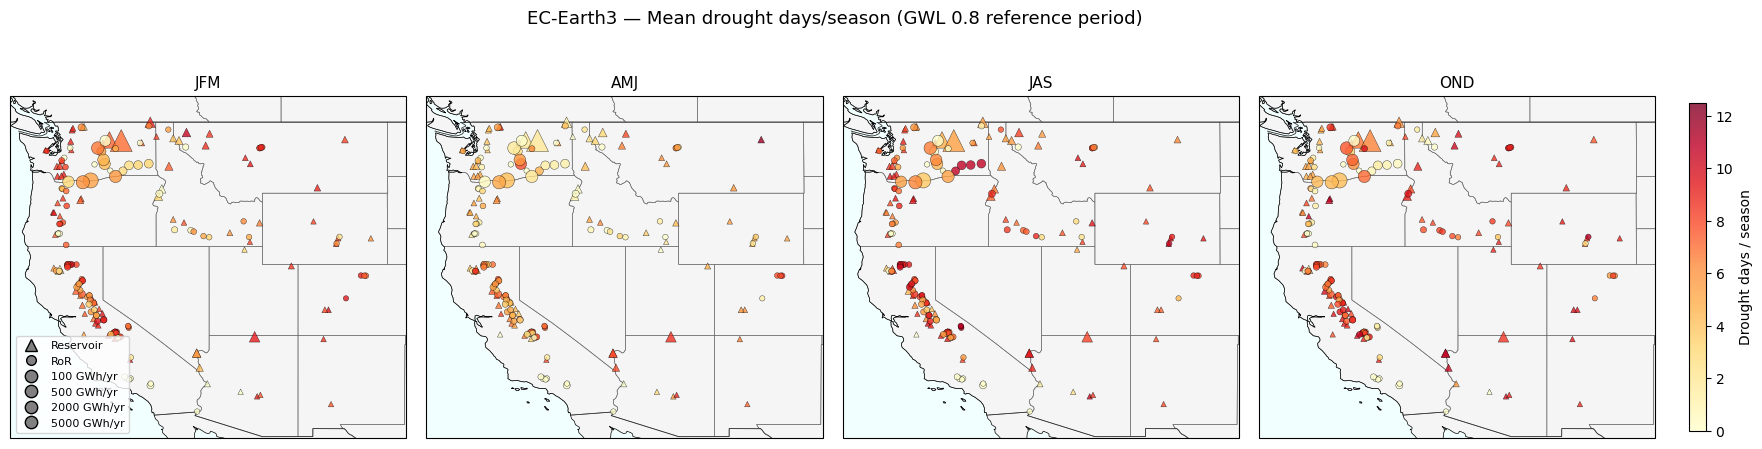

Saved → EC-Earth3_gwlref0.8_baseline_drought_days.png


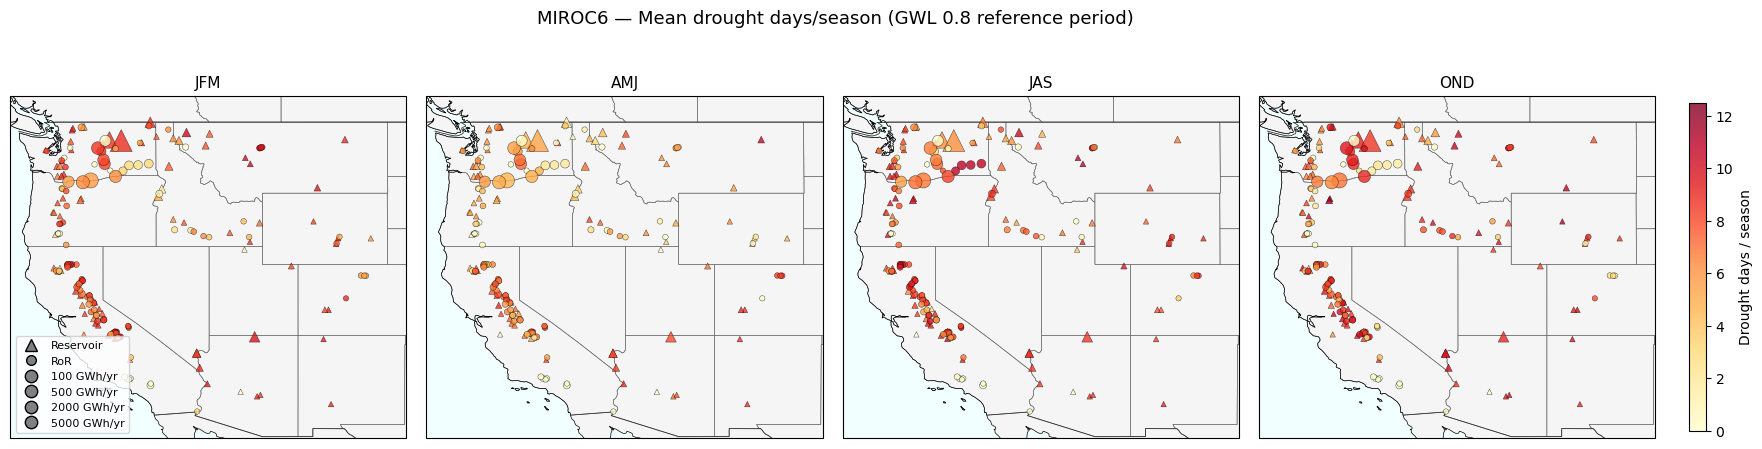

Saved → MIROC6_gwlref0.8_baseline_drought_days.png


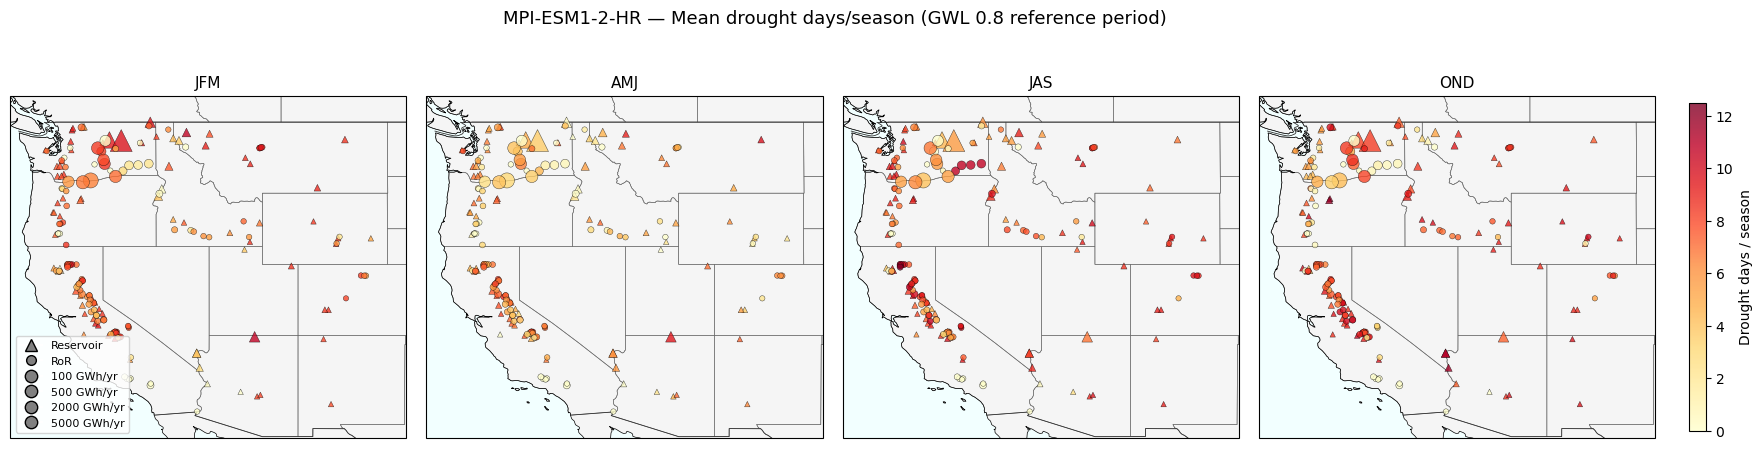

Saved → MPI-ESM1-2-HR_gwlref0.8_baseline_drought_days.png


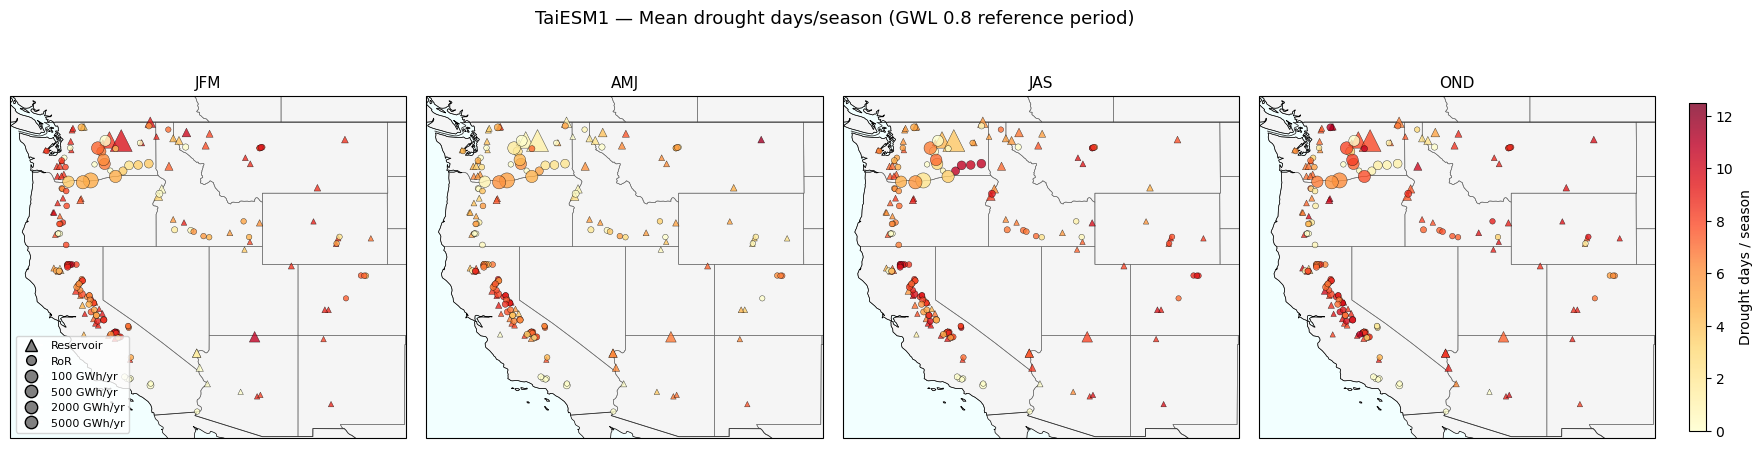

Saved → TaiESM1_gwlref0.8_baseline_drought_days.png


In [19]:
# ── Baseline maps: mean drought days/season during GWL 0.8 period ──────────
# Shared color scale across all models and seasons for comparability.
baseline_max = max(
    df["gwl_ref_days"].max()
    for df in all_results.values()
)
print(f"Global baseline max: {baseline_max:.1f} days/season")

for model, df_model in all_results.items():
    plot_seasonal_scatter(
        df_model            = df_model,
        value_col           = "gwl_ref_days",
        seasons             = seasons,
        title_prefix        = f"{model} — Mean drought days/season (GWL {reference_gwl} reference period)",
        cmap                = "YlOrRd",
        vmin                = 0,
        vmax                = baseline_max,
        fig_path            = fig_dir / f"{model}_gwlref{reference_gwl}_baseline_drought_days.png",
        scale_by_generation = True,
    )


Global change abs-max: 30.0 days/season


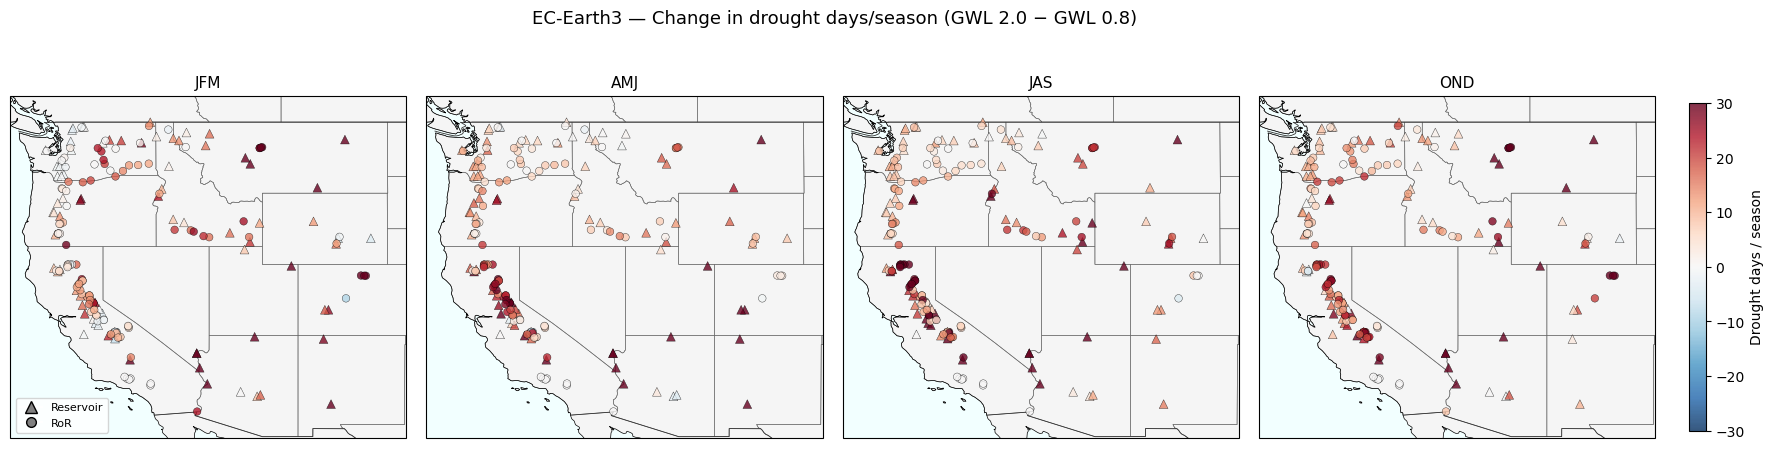

Saved → EC-Earth3_gwl2.0-0.8_change_drought_days.png


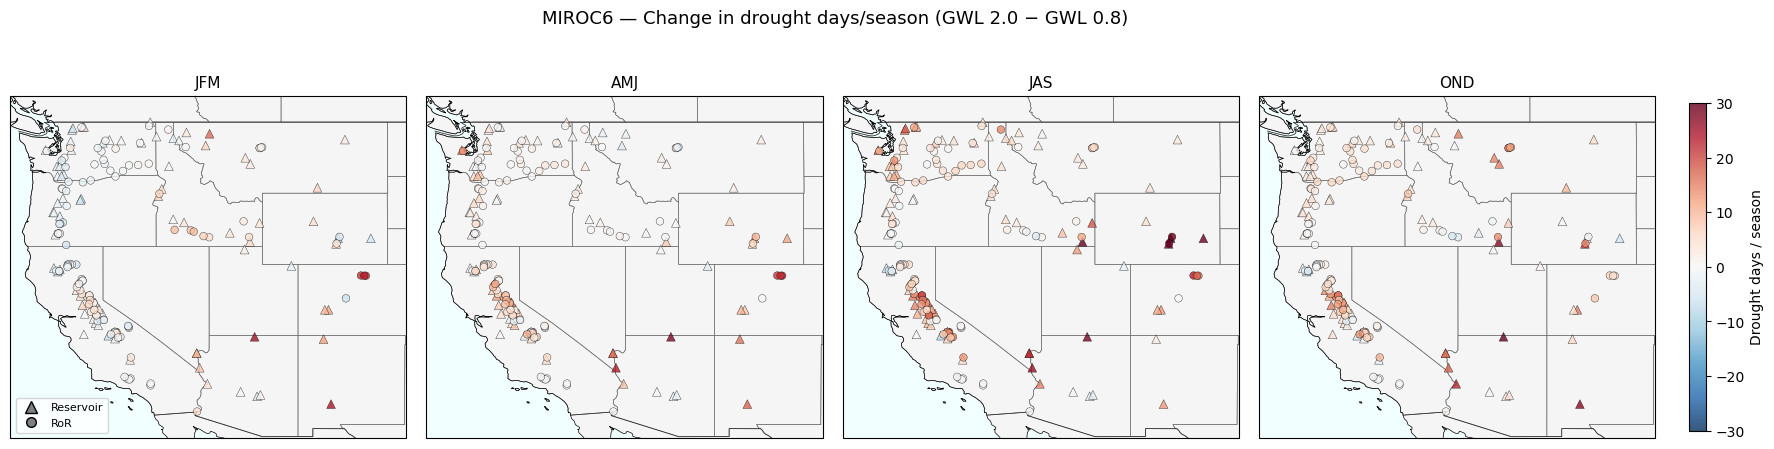

Saved → MIROC6_gwl2.0-0.8_change_drought_days.png


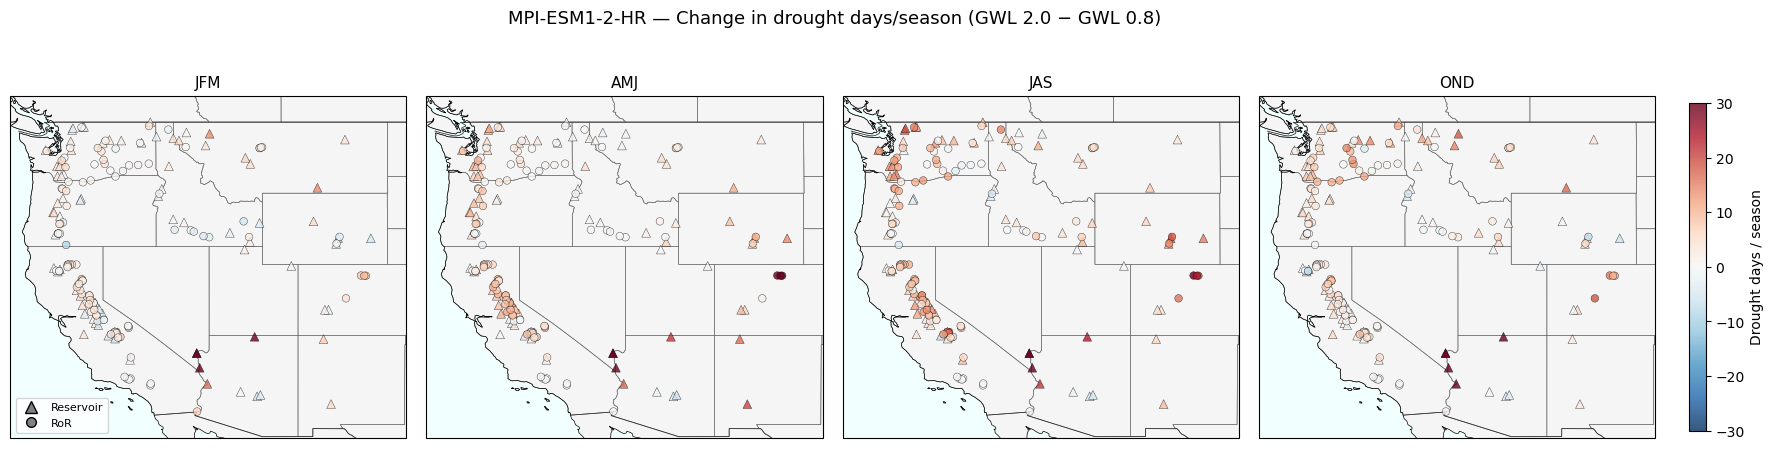

Saved → MPI-ESM1-2-HR_gwl2.0-0.8_change_drought_days.png


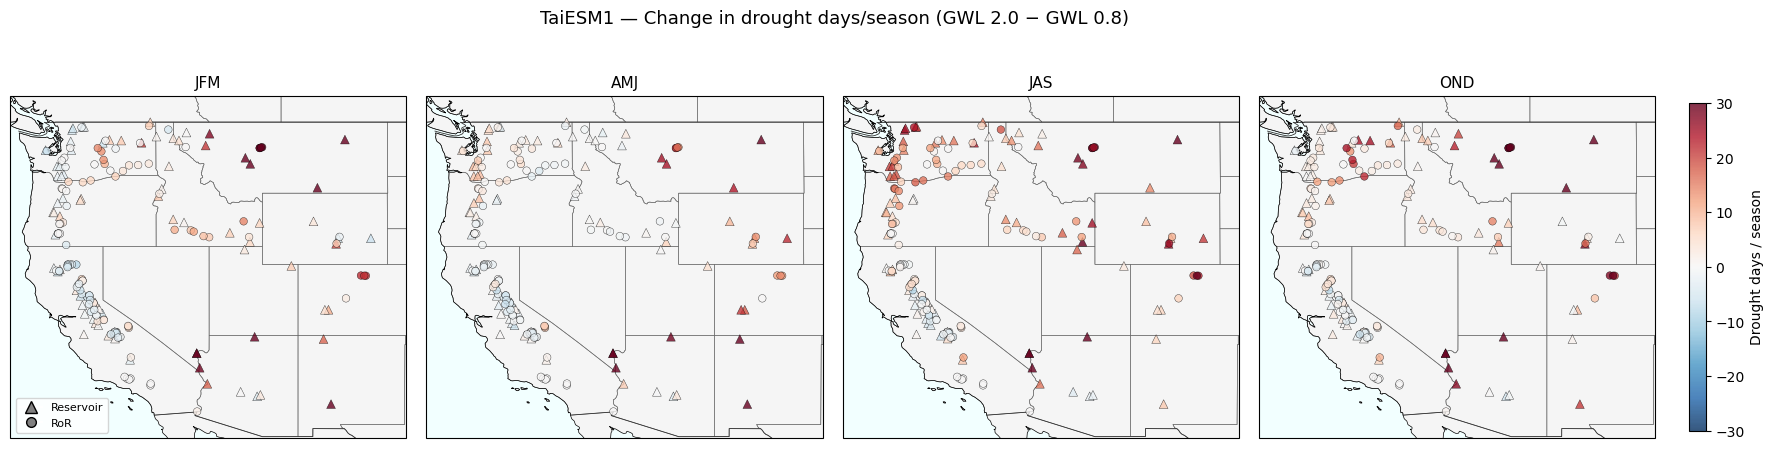

Saved → TaiESM1_gwl2.0-0.8_change_drought_days.png


In [ ]:
# ── Change maps: GWL 2.0 minus GWL 0.8 drought days/season ────────────────
# Shared symmetric color scale across all models and seasons.
change_abs_max = max(
    df["change_days"].abs().max()
    for df in all_results.values()
)
change_abs_max = 30
print(f"Global change abs-max: {change_abs_max:.1f} days/season")

for model, df_model in all_results.items():
    plot_seasonal_scatter(
        df_model            = df_model,
        value_col           = "change_days",
        seasons             = seasons,
        title_prefix        = (
            f"{model} — Change in drought days/season "
            f"(GWL {target_gwl} − GWL {reference_gwl})"
        ),
        cmap                = "RdBu_r",
        vmin                = -change_abs_max,
        vmax                = change_abs_max,
        fig_path            = fig_dir / f"{model}_gwl{target_gwl}-{reference_gwl}_change_drought_days.png",
        scale_by_generation = True,
    )
